# Mini Project for UNLV Data Science & Artificial Intelligence Bootcamp

## Description:
1. Create a mini project based on skills from the course so far:
- select an interesting public data set or form questions you are interested in answering and identify data needed to answer the questions
- the dataset must be accessed via an API (not a CSV that you simply download) and should have at least a few hundred rows
- use a Jupyter Notebook to access, analyse and visualize the data (include at least a few visualizations)
- formulating a Hypothesis test or creating a Tableau visualization are optional additional tasks

2. Prepare and present a 10 minute presentation by Tuesday April 21.
- use Jupyter Notebook/Lab (no slides)
- organise as:
    - questions
    - dataset & analysis
    - conclusion

# UNLV Data Analytics and AI mini project. 
#### April 21

I am using https://open-meteo.com/ to get hourly weather data for Red Rock Canyon as far back as I can from the website.

In [182]:
#Required installs to make an API request to open-meteo 
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas

In [1]:
#Importing necessary python libraries to complete mini project
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openmeteo_requests
import requests_cache
from retry_requests import retry

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [190]:
#This is the code Open-Meteo provided after selecting the data I wanted

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 36.137415, #cooridinates for Red Rock Canyon
	"longitude": -115.43129,
	"hourly": ["temperature_2m", "relative_humidity_2m", "precipitation_probability", "precipitation", "wind_speed_10m"],
	"timezone": "America/Los_Angeles",
	"wind_speed_unit": "mph",
	"temperature_unit": "fahrenheit",
	"precipitation_unit": "inch",
	"start_date": "2026-01-19",
	"end_date": "2026-04-24",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_precipitation_probability = hourly.Variables(2).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(3).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(4).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["precipitation_probability"] = hourly_precipitation_probability
hourly_data["precipitation"] = hourly_precipitation
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m

hourly_dataframe = pd.DataFrame(data = hourly_data)
hourly_dataframe

Coordinates: 36.144229888916016°N -115.44520568847656°E
Elevation: 1156.0 m asl
Timezone: b'America/Los_Angeles'b'GMT-7'
Timezone difference to GMT+0: -25200s


,date,temperature_2m,relative_humidity_2m,precipitation_probability,precipitation,wind_speed_10m
0,2026-01-19 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
1,2026-01-19 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2,2026-01-19 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN
3,2026-01-19 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN
4,2026-01-19 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2299,2026-04-24 19:00:00+00:00,65.991203,23.0,0.0,0.0,13.347225
2300,2026-04-24 20:00:00+00:00,64.011200,25.0,0.0,0.0,8.031422
2301,2026-04-24 21:00:00+00:00,62.931202,26.0,0.0,0.0,7.436133
2302,2026-04-24 22:00:00+00:00,61.491203,29.0,0.0,0.0,10.693234


In [191]:
#Checking the df information
hourly_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   date                       2304 non-null   datetime64[ns, UTC]
 1   temperature_2m             1576 non-null   float32            
 2   relative_humidity_2m       1576 non-null   float32            
 3   precipitation_probability  1603 non-null   float32            
 4   precipitation              1576 non-null   float32            
 5   wind_speed_10m             1576 non-null   float32            
dtypes: datetime64[ns, UTC](1), float32(5)
memory usage: 63.1 KB


In [192]:
#Checking description of df
hourly_dataframe.describe()

,temperature_2m,relative_humidity_2m,precipitation_probability,precipitation,wind_speed_10m
count,1576.000000,1576.000000,1603.000000,1576.000000,1576.000000
mean,62.193298,24.320272,0.976918,0.000215,9.715382
std,11.731261,14.533463,6.417652,0.002570,7.237218
min,29.587101,5.000000,0.000000,0.000000,0.000000
25%,54.697098,14.000000,0.000000,0.000000,4.644095
50%,62.617104,19.000000,0.000000,0.000000,7.599218
75%,70.267105,31.000000,0.000000,0.000000,13.005419
max,89.167099,92.000000,88.000000,0.047244,44.516861


In [193]:
#Looking at the rows with missing data
hourly_dataframe[hourly_dataframe['temperature_2m'].isnull()]

,date,temperature_2m,relative_humidity_2m,precipitation_probability,precipitation,wind_speed_10m
0,2026-01-19 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN
1,2026-01-19 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN
2,2026-01-19 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN
3,2026-01-19 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN
4,2026-01-19 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
723,2026-02-18 03:00:00+00:00,NaN,NaN,81.0,NaN,NaN
724,2026-02-18 04:00:00+00:00,NaN,NaN,88.0,NaN,NaN
725,2026-02-18 05:00:00+00:00,NaN,NaN,87.0,NaN,NaN
726,2026-02-18 06:00:00+00:00,NaN,NaN,55.0,NaN,NaN


In [165]:
#Looking at the data for the first row that has data for all columns
hourly_dataframe.iloc[728]

date                         2026-02-18 08:00:00+00:00
temperature_2m                               33.681198
relative_humidity_2m                              70.0
precipitation_probability                          7.0
precipitation                                      0.0
wind_speed_10m                               27.214281
Name: 728, dtype: object

In [194]:
#Dropping all rows with any missing values
weather_df = hourly_dataframe.dropna()
weather_df

,date,temperature_2m,relative_humidity_2m,precipitation_probability,precipitation,wind_speed_10m
728,2026-02-18 08:00:00+00:00,33.681198,70.0,7.0,0.0,27.214281
729,2026-02-18 09:00:00+00:00,33.861198,70.0,5.0,0.0,24.530621
730,2026-02-18 10:00:00+00:00,34.491199,68.0,6.0,0.0,15.087731
731,2026-02-18 11:00:00+00:00,35.121201,70.0,5.0,0.0,13.335973
732,2026-02-18 12:00:00+00:00,36.111198,65.0,3.0,0.0,9.304415
...,...,...,...,...,...,...
2299,2026-04-24 19:00:00+00:00,65.991203,23.0,0.0,0.0,13.347225
2300,2026-04-24 20:00:00+00:00,64.011200,25.0,0.0,0.0,8.031422
2301,2026-04-24 21:00:00+00:00,62.931202,26.0,0.0,0.0,7.436133
2302,2026-04-24 22:00:00+00:00,61.491203,29.0,0.0,0.0,10.693234


In [195]:
#Checking df information and confirming all rows with missing values have been removed
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1576 entries, 728 to 2303
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   date                       1576 non-null   datetime64[ns, UTC]
 1   temperature_2m             1576 non-null   float32            
 2   relative_humidity_2m       1576 non-null   float32            
 3   precipitation_probability  1576 non-null   float32            
 4   precipitation              1576 non-null   float32            
 5   wind_speed_10m             1576 non-null   float32            
dtypes: datetime64[ns, UTC](1), float32(5)
memory usage: 55.4 KB


In [196]:
#Checking df summary and finding that everything looks normal
weather_df.describe()

,temperature_2m,relative_humidity_2m,precipitation_probability,precipitation,wind_speed_10m
count,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000
mean,62.193298,24.320272,0.664975,0.000215,9.715382
std,11.731261,14.533463,4.805819,0.002570,7.237218
min,29.587101,5.000000,0.000000,0.000000,0.000000
25%,54.697098,14.000000,0.000000,0.000000,4.644095
50%,62.617104,19.000000,0.000000,0.000000,7.599218
75%,70.267105,31.000000,0.000000,0.000000,13.005419
max,89.167099,92.000000,73.000000,0.047244,44.516861


# Variable Codebook

| Variable| Valid time | Unit | Description |
| :--- | :--- | :--- | :--- |
|temperature_2m	| Instant | °F | Air temperature at 2 meters above ground|
|relative_humidity_2m| Instant | % | Relative humidity at 2 meters above ground|
|precipitation_probability | Preceding hour probability | % | 	Probability of precipitation with more than 0.1 mm of the preceding hour. Probability is based on ensemble weather models with 0.25° (~27 km) resolution. 30 different simulations are computed to better represent future weather conditions |
| precipitation | Preceding hour sum | % | 	Total precipitation (rain, showers, snow) sum of the preceding hour |
| wind_speed_10m | Instant | mph | Wind speed at 10 meters above ground |

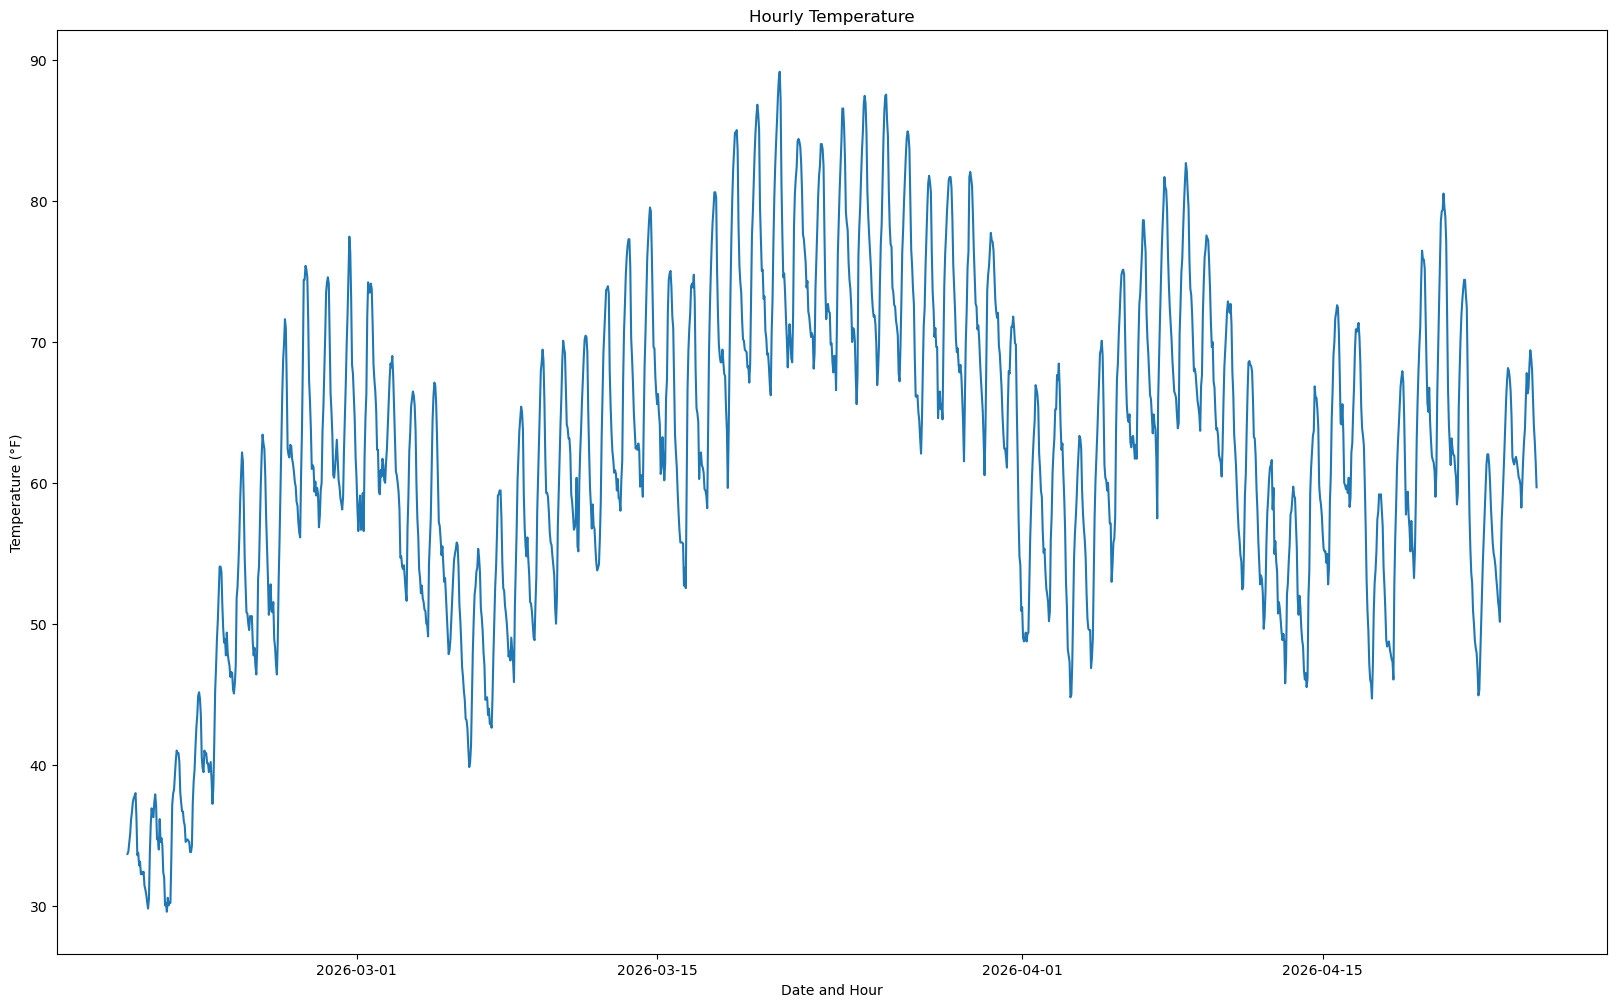

In [197]:
#Plotting line graph of temperature

#Defining x and y points
x_points = weather_df['date']
y_points = weather_df['temperature_2m']

#Graphing x and y in line graph
plt.plot(x_points, y_points)
plt.title('Hourly Temperature')
plt.xlabel('Date and Hour')
plt.ylabel('Temperature (°F)')
plt.show()
           

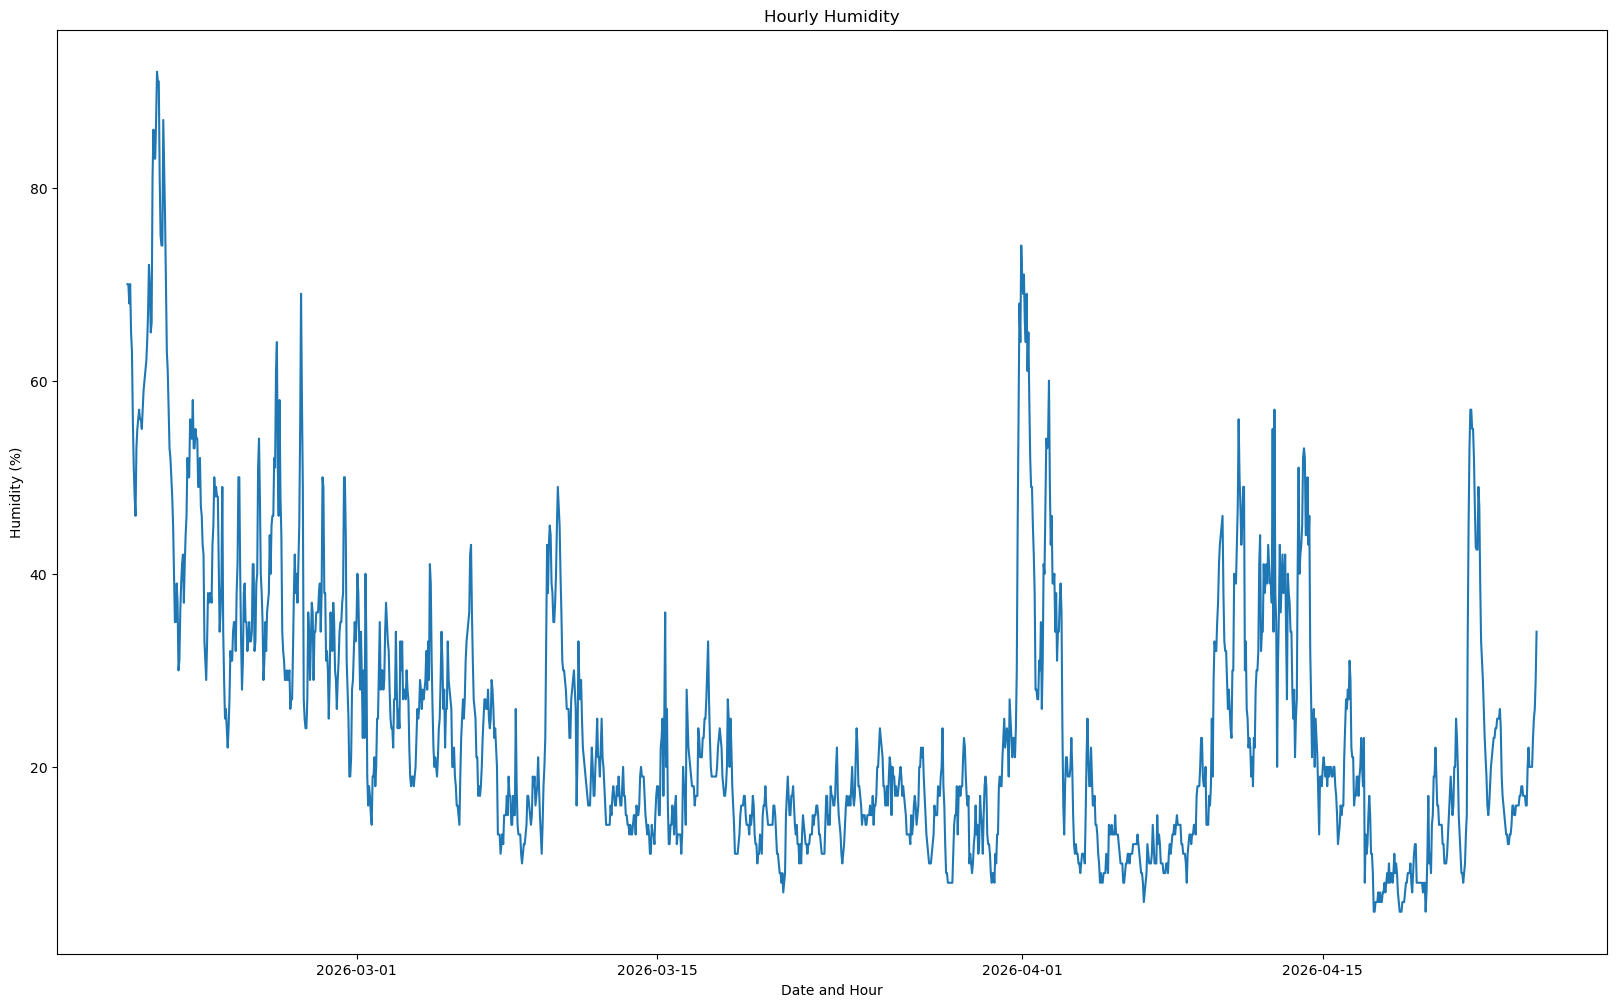

In [198]:
#Plotting line graph of humidity

#Defining x and y points
x_points = weather_df['date']
y_points = weather_df['relative_humidity_2m']

#Graphing x and y in line graph
plt.plot(x_points, y_points)
plt.title('Hourly Humidity')
plt.xlabel('Date and Hour')
plt.ylabel('Humidity (%)')
plt.show()
           

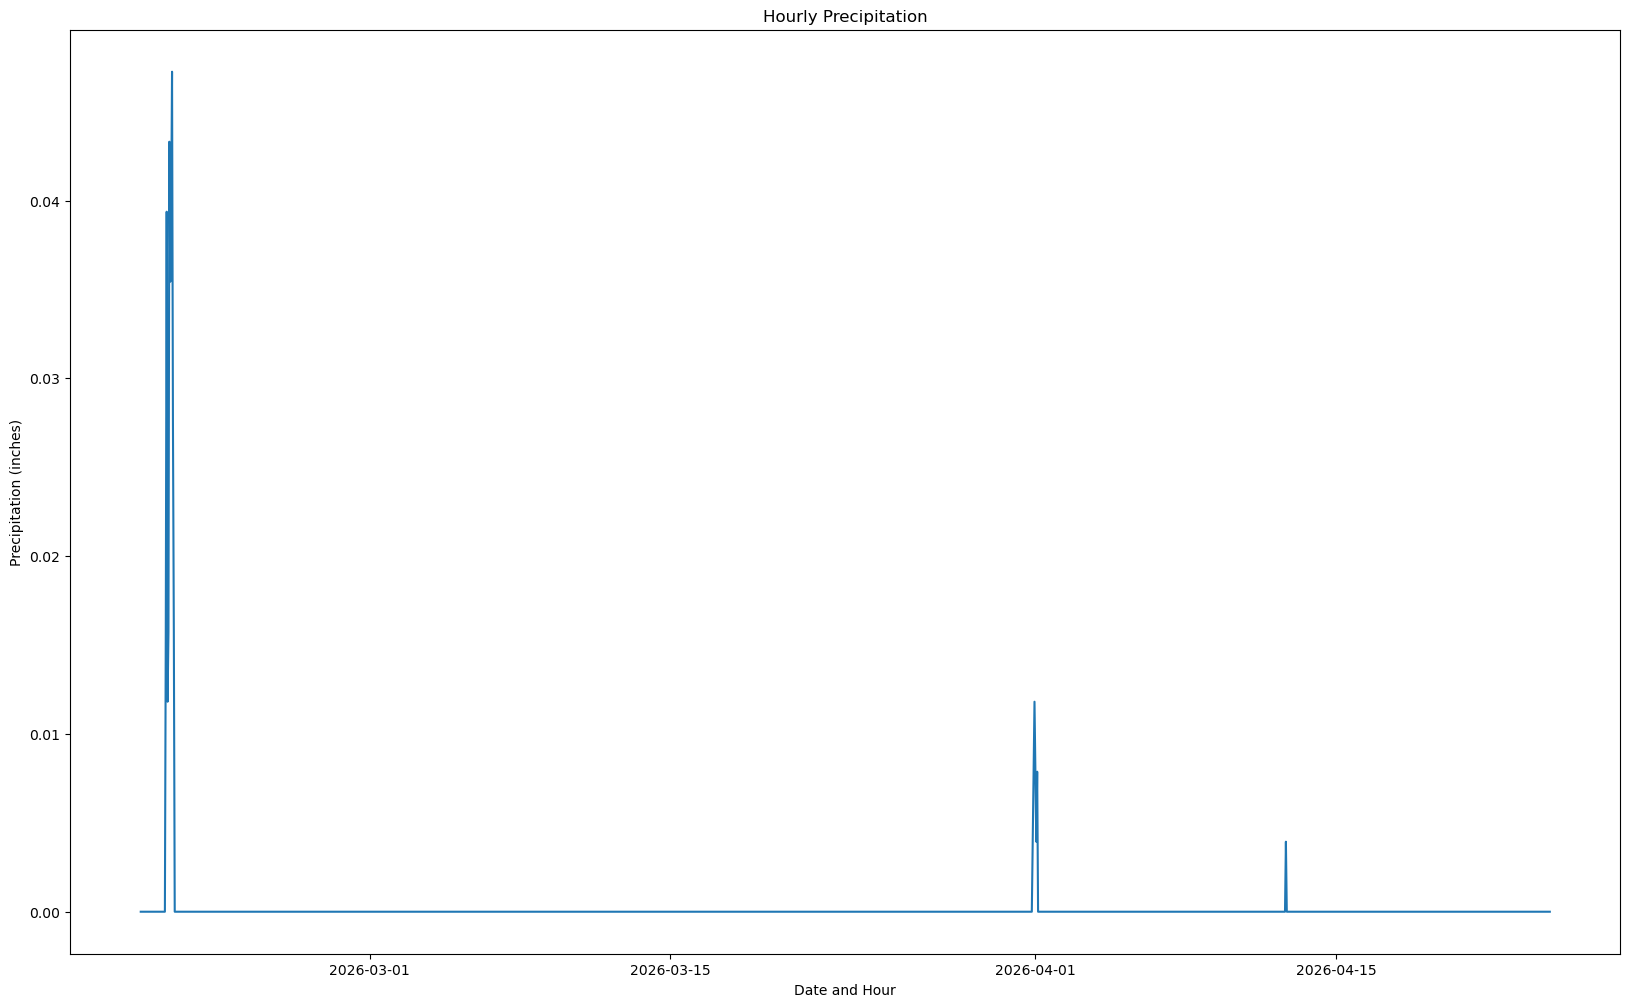

In [199]:
#Plotting line graph of precipitation

#Defining x and y points
x_points = weather_df['date']
y_points = weather_df['precipitation']

#Graphing x and y in line graph
plt.plot(x_points, y_points)
plt.title('Hourly Precipitation')
plt.xlabel('Date and Hour')
plt.ylabel('Precipitation (inches)')
plt.show()

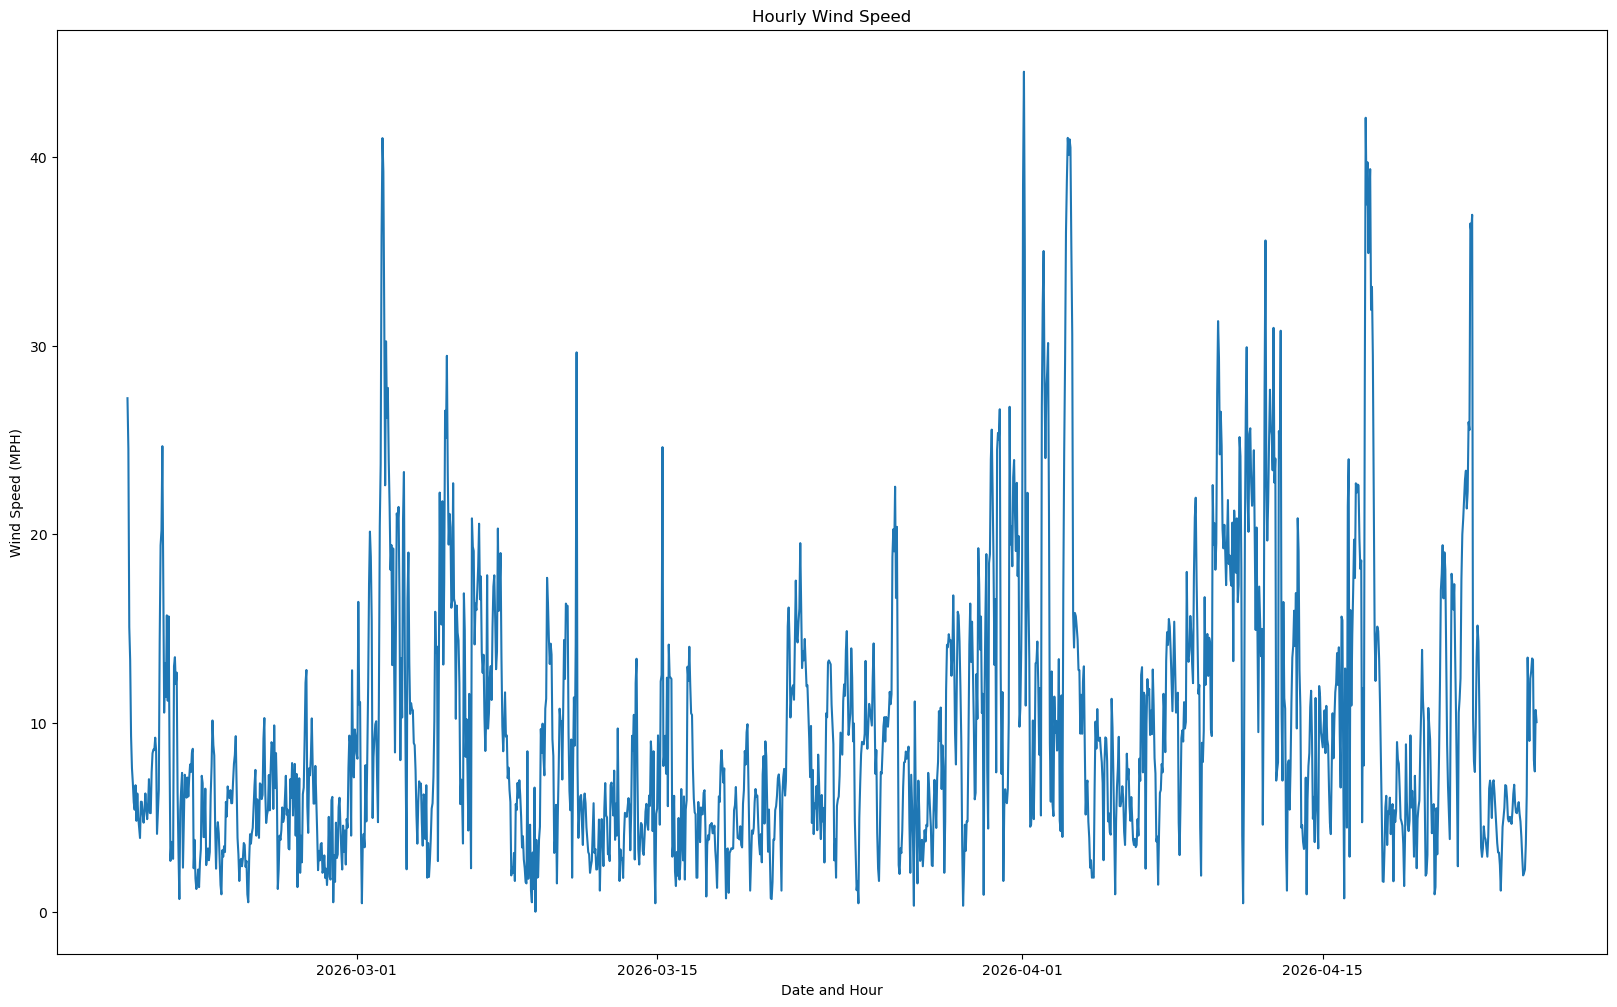

In [200]:
#Plotting line graph of wind speed

#Defining x and y points
x_points = weather_df['date']
y_points = weather_df['wind_speed_10m']

#Graphing x and y in line graph
plt.plot(x_points, y_points)
plt.title('Hourly Wind Speed')
plt.xlabel('Date and Hour')
plt.ylabel('Wind Speed (MPH)')
plt.show()

# I wanted to create new column in the dataframe called Ideal Climbing Conditions

## My ideal climbing conditions:
- Ideally, I would want to climb in the hours between 10:00 to 19:00. Since, I am currently unemployed and have the freedom to climb during the day every day. Ideal date would date >=10:00 & <=19:00.
- In Red Rock Canyon, the rock type is sandstone and the local ethics is to not climb on wet rock. Sandstone is a fragile and pourous stone that needs to be dry when climbed. Sandstone usually 24 to 48 hours to dry. I will need to create a new column for a rolling sum of the precipitation for the last 48 hours. I will also need to create another new column to indicate if the rock is dry and definite dry rock as if rolling sum of precipation is equal to 0.
- My ideal temputare to climb in is from °45 to °65 (temperature_2m >=45 & <=65)]
- My ideal humidity is less than 50%
- My ideal wind speed is less than 25 mph (wind_speed_10m <=25)

#### Question 1: How many hours were considered ideal climbing based on my requirements from 2026-02-18 08:00 to 2026-04-24 23:00?

In [238]:
#Create column for rolling precipitation for the last 48 hours
weather_df['Last_48h_precip_total'] = weather_df['precipitation'].rolling(window=48, min_periods=1).sum()
weather_df['Last_48h_precip_total'] 

/var/folders/p4/vxx4n3kn4q1grbl878lw90k80000gp/T/ipykernel_3685/681846499.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_df['Last_48h_precip_total'] = weather_df['precipitation'].rolling(window=48, min_periods=1).sum()


728     0.0
729     0.0
730     0.0
731     0.0
732     0.0
       ... 
2299    0.0
2300    0.0
2301    0.0
2302    0.0
2303    0.0
Name: Last_48h_precip_total, Length: 1576, dtype: float64

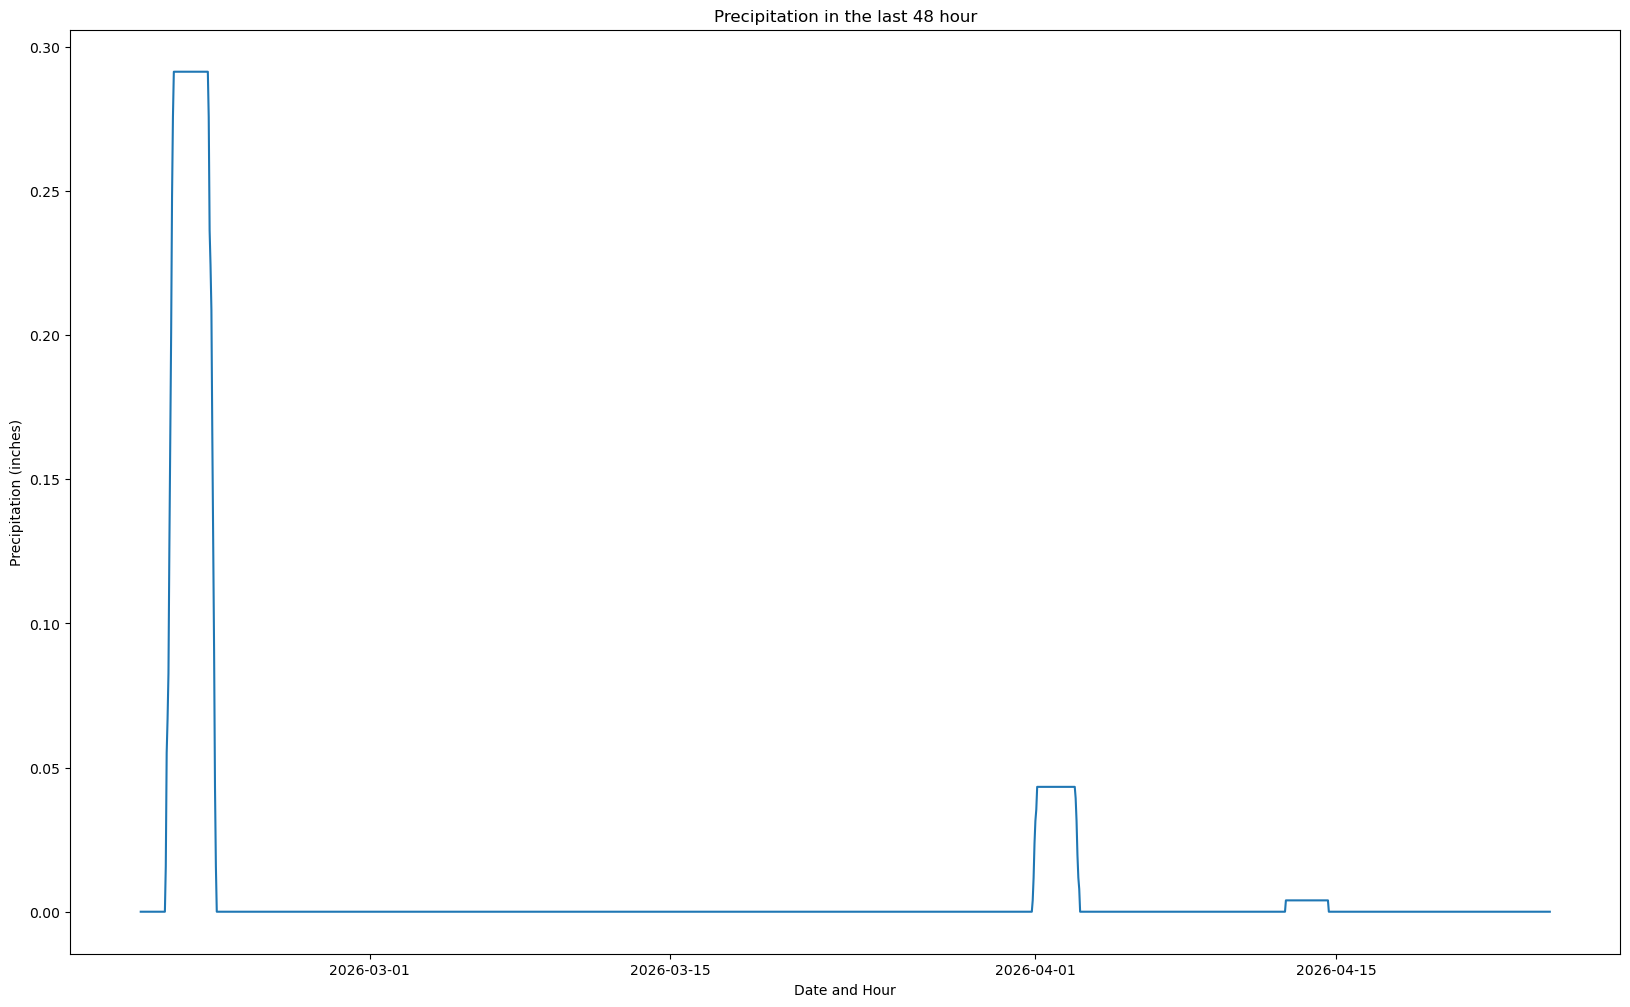

In [202]:
#Plotting line graph of precipitation for the last 48 hours

#Defining x and y points
x_points = weather_df['date']
y_points = weather_df['Last_48h_precip_total']

#Graphing x and y in line graph
plt.plot(x_points, y_points)
plt.title('Precipitation in the last 48 hour')
plt.xlabel('Date and Hour')
plt.ylabel('Precipitation (inches)')
plt.show()

In [203]:
#filtering dataframe where Last_48h_precip_total is greater than 0
filter_48_rain_df = weather_df[weather_df['Last_48h_precip_total'] > 0]
filter_48_rain_df

,date,temperature_2m,relative_humidity_2m,precipitation_probability,precipitation,wind_speed_10m,Last_48h_precip_total
756,2026-02-19 12:00:00+00:00,36.381199,81.0,15.0,0.015748,8.396949,0.015748
757,2026-02-19 13:00:00+00:00,36.291199,86.0,40.0,0.039370,8.594274,0.055118
758,2026-02-19 14:00:00+00:00,37.371201,83.0,55.0,0.011811,8.562189,0.066929
759,2026-02-19 15:00:00+00:00,37.911201,83.0,60.0,0.015748,9.223387,0.082677
760,2026-02-19 16:00:00+00:00,37.101200,87.0,73.0,0.043307,8.547565,0.125984
...,...,...,...,...,...,...,...
2051,2026-04-14 11:00:00+00:00,61.087101,27.0,0.0,0.000000,11.709579,0.003937
2052,2026-04-14 12:00:00+00:00,62.167103,21.0,1.0,0.000000,9.127947,0.003937
2053,2026-04-14 13:00:00+00:00,63.337101,24.0,1.0,0.000000,4.926481,0.003937
2054,2026-04-14 14:00:00+00:00,63.697102,26.0,1.0,0.000000,6.085298,0.003937


In [204]:
#Viewing all 158 rows to make sure calculations for the rolling 48 hours
from IPython.display import display, HTML
display(HTML(filter_48_rain_df.to_html()))

,date,temperature_2m,relative_humidity_2m,precipitation_probability,precipitation,wind_speed_10m,Last_48h_precip_total
756,2026-02-19 12:00:00+00:00,36.381199,81.0,15.0,0.015748,8.396949,0.015748
757,2026-02-19 13:00:00+00:00,36.291199,86.0,40.0,0.039370,8.594274,0.055118
758,2026-02-19 14:00:00+00:00,37.371201,83.0,55.0,0.011811,8.562189,0.066929
759,2026-02-19 15:00:00+00:00,37.911201,83.0,60.0,0.015748,9.223387,0.082677
760,2026-02-19 16:00:00+00:00,37.101200,87.0,73.0,0.043307,8.547565,0.125984
761,2026-02-19 17:00:00+00:00,34.717102,92.0,68.0,0.035433,4.124824,0.161417
762,2026-02-19 18:00:00+00:00,34.807098,91.0,62.0,0.039370,5.303153,0.200787
763,2026-02-19 19:00:00+00:00,33.997101,91.0,47.0,0.047244,6.440851,0.248031
764,2026-02-19 20:00:00+00:00,36.157101,81.0,16.0,0.027559,14.348224,0.275591
765,2026-02-19 21:00:00+00:00,34.537102,75.0,11.0,0.015748,19.410406,0.291339


In [205]:
#Creating new variable call is_dry with true and false values if Last_48h_precip_total is greater than 0
weather_df['is_dry'] = np.where(weather_df['Last_48h_precip_total'] > 0, False, True)
weather_df['is_dry']

/var/folders/p4/vxx4n3kn4q1grbl878lw90k80000gp/T/ipykernel_3685/3056255814.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_df['is_dry'] = np.where(weather_df['Last_48h_precip_total'] > 0, False, True)


728     True
729     True
730     True
731     True
732     True
        ... 
2299    True
2300    True
2301    True
2302    True
2303    True
Name: is_dry, Length: 1576, dtype: bool

In [206]:
weather_df.head()

,date,temperature_2m,relative_humidity_2m,precipitation_probability,precipitation,wind_speed_10m,Last_48h_precip_total,is_dry
728,2026-02-18 08:00:00+00:00,33.681198,70.0,7.0,0.0,27.214281,0.0,True
729,2026-02-18 09:00:00+00:00,33.861198,70.0,5.0,0.0,24.530621,0.0,True
730,2026-02-18 10:00:00+00:00,34.491199,68.0,6.0,0.0,15.087731,0.0,True
731,2026-02-18 11:00:00+00:00,35.121201,70.0,5.0,0.0,13.335973,0.0,True
732,2026-02-18 12:00:00+00:00,36.111198,65.0,3.0,0.0,9.304415,0.0,True


In [100]:
#Creating date column
weather_df['only_date'] = weather_df['date'].dt.date

#Creatiung time column
weather_df['time'] = weather_df['date'].dt.time

/var/folders/p4/vxx4n3kn4q1grbl878lw90k80000gp/T/ipykernel_3685/4246935053.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_df['only_date'] = weather_df['date'].dt.date
/var/folders/p4/vxx4n3kn4q1grbl878lw90k80000gp/T/ipykernel_3685/4246935053.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_df['time'] = weather_df['date'].dt.time


In [101]:
weather_df.head()

,date,temperature_2m,relative_humidity_2m,precipitation_probability,precipitation,wind_speed_10m,Last_48h_precip_total,is_dry,only_date,time
728,2026-02-18 08:00:00+00:00,33.681198,70.0,7.0,0.0,27.214281,0.0,True,2026-02-18,08:00:00
729,2026-02-18 09:00:00+00:00,33.861198,70.0,5.0,0.0,24.530621,0.0,True,2026-02-18,09:00:00
730,2026-02-18 10:00:00+00:00,34.491199,68.0,6.0,0.0,15.087731,0.0,True,2026-02-18,10:00:00
731,2026-02-18 11:00:00+00:00,35.121201,70.0,5.0,0.0,13.335973,0.0,True,2026-02-18,11:00:00
732,2026-02-18 12:00:00+00:00,36.111198,65.0,3.0,0.0,9.304415,0.0,True,2026-02-18,12:00:00


In [207]:
#Creating new variable called ideal to represent ideal climbing with True and False values. 
#Ideal will be true when temperature_2m is equal to or greater than 45 and equal to or less than 65, 
#relative_humidity_2m less than 50, wind_speed_10m is less than 25, is_dry is equal to True, and 
#Time is between 10:00 and 19:00 
weather_df['ideal'] = np.where((weather_df['temperature_2m'] >=45) &
                               (weather_df['temperature_2m'] <=65) &
                                (weather_df['relative_humidity_2m'] < 50) &
                                (weather_df['wind_speed_10m'] < 25) &
                                (weather_df['is_dry'] == True) &
                                (weather_df['date'].dt.hour >= 10) & 
                                (weather_df['date'].dt.hour <= 19),
                                 True, False)

/var/folders/p4/vxx4n3kn4q1grbl878lw90k80000gp/T/ipykernel_3685/746181649.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_df['ideal'] = np.where((weather_df['temperature_2m'] >=45) &


In [210]:
weather_df

,date,temperature_2m,relative_humidity_2m,precipitation_probability,precipitation,wind_speed_10m,Last_48h_precip_total,is_dry,ideal
728,2026-02-18 08:00:00+00:00,33.681198,70.0,7.0,0.0,27.214281,0.0,True,False
729,2026-02-18 09:00:00+00:00,33.861198,70.0,5.0,0.0,24.530621,0.0,True,False
730,2026-02-18 10:00:00+00:00,34.491199,68.0,6.0,0.0,15.087731,0.0,True,False
731,2026-02-18 11:00:00+00:00,35.121201,70.0,5.0,0.0,13.335973,0.0,True,False
732,2026-02-18 12:00:00+00:00,36.111198,65.0,3.0,0.0,9.304415,0.0,True,False
...,...,...,...,...,...,...,...,...,...
2299,2026-04-24 19:00:00+00:00,65.991203,23.0,0.0,0.0,13.347225,0.0,True,False
2300,2026-04-24 20:00:00+00:00,64.011200,25.0,0.0,0.0,8.031422,0.0,True,False
2301,2026-04-24 21:00:00+00:00,62.931202,26.0,0.0,0.0,7.436133,0.0,True,False
2302,2026-04-24 22:00:00+00:00,61.491203,29.0,0.0,0.0,10.693234,0.0,True,False


In [211]:
#Finding total counts for True and False for ideal column
Ideal_climbing_hours = weather_df['ideal'].value_counts()
print(Ideal_climbing_hours)

#Answer to the question 1: There were 140 hours from 2026-02-18 08:00 to 2026-04-24 23:00 that were ideal for climbing

ideal
False    1435
True      141
Name: count, dtype: int64


/var/folders/p4/vxx4n3kn4q1grbl878lw90k80000gp/T/ipykernel_3685/3045017979.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_df['ideal_str'] = weather_df['ideal'].map({True: 'True', False: 'False'})


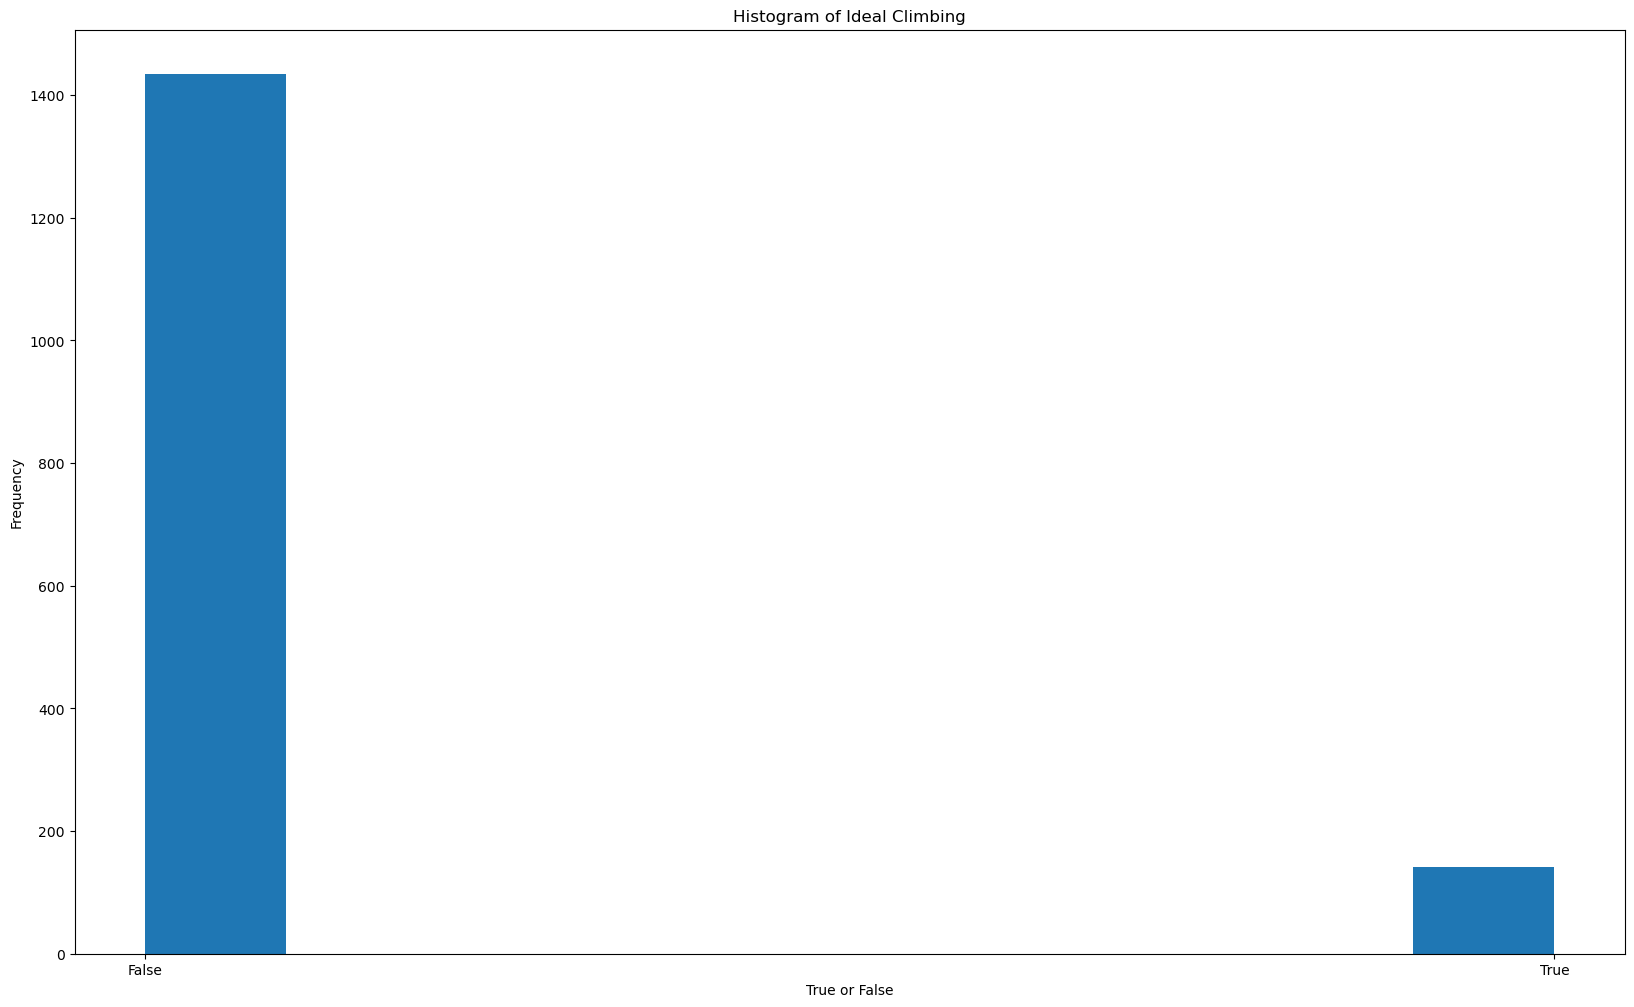

In [214]:
#Converting ideal column form boolean to string data to plot histogram
weather_df['ideal_str'] = weather_df['ideal'].map({True: 'True', False: 'False'})

#plotting a histogram for ideal 
plt.hist(weather_df['ideal_str'])
plt.title('Histogram of Ideal Climbing')
plt.xlabel('True or False')
plt.ylabel('Frequency')
plt.show()

In [178]:
#Creating a function to determine if it is okay to climb and return reasons why it is not okay to climb

def okay_to_climb(temperature_2m, relative_humidity_2m, wind_speed_10m, Last_48h_precip_total):
    """
    Evaluates climbing conditions based on my ideal conditions

    Arg: temperature_2m : Temperature in Fahrenheit
         relative_humidity_2m : Humidity percentage
         wind_speed_10m : Wind speed in miles per hour
         Last_48h_precip_total : Rolling total of rain in the last 48 hours
    """

    reasons = []
    #Check if Temperature is okay
    if temperature_2m <= 45:
        reasons.append(f'Too cold ({temperature_2m} °F).')
    elif temperature_2m >= 65:
        reasons.append(f'Too hot ({temperature_2m} °F).')

    #Check if Humidity is okay
    if relative_humidity_2m > 50:
        reasons.append(f'Too humid ({relative_humidity_2m} %).')

    #Check if Wind speed is okay
    if wind_speed_10m > 25:
        reasons.append(f'Too windy ({wind_speed_10m} mph).')

    #Check if there was rain in the last 48 hours
    if Last_48h_precip_total > 0:
        reasons.append(f'Wet rock ({Last_48h_precip_total} inches in the last 48 hours).')

    if not reasons:
        return 'Conditions are ideal for climbing'
    else:
        return 'Conditions are not ideal: ' + ' | '.join(reasons)

In [181]:
okay_to_climb(70,51,27,0.01)

'Conditions are not ideal: Too hot (70 °F). | Too humid (51 %). | Too windy (27 mph). | Wet rock (0.01 inches in the last 48 hours).'

In [180]:
okay_to_climb(50,30,20,0)

'Conditions are ideal for climbing'

### Question 2: What were the max, min, and means for temperature, humidity, and wind speed and total precipitation for each date?
### Question 3: What were the max, min, and means for temperature, humidity, and wind speed and total precipitation for each month?

In [127]:
#creating new df of daily averages for only columns with numbers
weather_daily_ave_df = weather_df.groupby(weather_df['date'].dt.date).agg(
    High_temp=('temperature_2m', 'max'),
    Low_temp=('temperature_2m', 'min'),
    Ave_temp=('temperature_2m', 'mean'),
    High_humid=('relative_humidity_2m', 'max'),
    Low_humid=('relative_humidity_2m', 'min'),
    Ave_humid=('relative_humidity_2m', 'mean'),
    High_wind=('wind_speed_10m', 'max'),
    Low_wind=('wind_speed_10m', 'min'),
    Ave_wind=('wind_speed_10m', 'mean'),
    total_precip=('precipitation', 'sum')
)
#printing daily average df
weather_daily_ave_df

,High_temp,Low_temp,Ave_temp,High_humid,Low_humid,Ave_humid,High_wind,Low_wind,Ave_wind,total_precip
date,,,,,,,,,,
2026-02-18,38.001202,32.241199,35.166199,70.0,46.0,58.750000,27.214281,3.906753,9.506201,0.000000
2026-02-19,37.911201,29.811199,33.994587,92.0,55.0,73.166664,24.671991,4.124824,8.586934,0.291339
2026-02-20,41.017097,29.587101,35.380848,87.0,30.0,49.458332,17.946262,0.671100,8.490693,0.000000
2026-02-21,45.157101,33.817101,38.909599,58.0,31.0,48.583332,8.634936,1.204661,5.061174,0.000000
2026-02-22,54.067101,37.237099,45.753353,50.0,24.0,38.250000,10.135856,0.922339,4.358798,0.000000
...,...,...,...,...,...,...,...,...,...,...
2026-04-20,78.771202,60.411201,70.425743,22.0,11.0,15.927083,16.453739,2.807409,9.945560,0.000000
2026-04-21,73.371201,52.491203,64.566200,61.0,11.0,24.541666,30.440464,4.529580,14.181244,0.000000
2026-04-22,60.051201,46.731201,53.863697,57.0,22.0,36.250000,26.107813,1.789600,12.530932,0.000000


In [129]:
#summary description of the daily average df
weather_daily_ave_df.describe()

,High_temp,Low_temp,Ave_temp,High_humid,Low_humid,Ave_humid,High_wind,Low_wind,Ave_wind,total_precip
count,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000
mean,71.072227,53.287685,62.072525,37.045456,15.803030,24.708490,19.261633,2.186631,9.763135,0.005130
std,11.643680,9.442526,10.370518,19.357712,8.997811,12.969993,9.547403,2.132224,4.889833,0.035971
min,37.911201,29.587101,33.994587,10.000000,5.000000,7.250000,6.843904,0.000000,3.505219,0.000000
25%,66.577099,46.495625,56.617100,22.000000,10.000000,15.145833,11.179800,0.922339,5.690770,0.000000
50%,72.202103,53.392099,63.412102,33.000000,13.000000,20.395834,17.230251,1.620842,8.574220,0.000000
75%,79.345627,60.220177,70.071159,50.000000,19.750000,34.093749,25.748857,2.532359,13.177052,0.000000
max,89.167099,68.197098,77.017097,92.000000,55.000000,73.166664,44.516861,13.279568,22.075386,0.291339


In [217]:
#creating new df of monthly averages for only columns with numbers
weather_monthly_ave_df = weather_df.groupby(weather_df['date'].dt.month).agg(
    High_temp=('temperature_2m', 'max'),
    Low_temp=('temperature_2m', 'min'),
    Ave_temp=('temperature_2m', 'mean'),
    High_humid=('relative_humidity_2m', 'max'),
    Low_humid=('relative_humidity_2m', 'min'),
    Ave_humid=('relative_humidity_2m', 'mean'),
    High_wind=('wind_speed_10m', 'max'),
    Low_wind=('wind_speed_10m', 'min'),
    Ave_wind=('wind_speed_10m', 'mean'),
    total_precip=('precipitation', 'sum')
)
#printing daily average df
weather_monthly_ave_df

,High_temp,Low_temp,Ave_temp,High_humid,Low_humid,Ave_humid,High_wind,Low_wind,Ave_wind,total_precip
date,,,,,,,,,,
2,77.467102,29.587101,50.210518,92.0,19.0,43.750000,27.214281,0.500208,6.044524,0.291339
3,89.167099,39.847099,66.567307,74.0,7.0,19.541666,40.998173,0.000000,9.092713,0.023622
4,82.687103,44.707100,61.869221,71.0,5.0,21.857204,44.516861,0.447400,12.151155,0.023622


## Question 4 - Can I build a function in python to apply to forecast data to see when would be a good time for me to go outside a climb?

In [ ]:
#Getting forecast data from open_meteo

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 36.137415,
	"longitude": -115.43129,
	"hourly": ["temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"],
	"timezone": "America/Los_Angeles",
	"past_days": 7,
	"forecast_days": 7,
	"wind_speed_unit": "mph",
	"temperature_unit": "fahrenheit",
	"precipitation_unit": "inch",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(2).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd() + response.UtcOffsetSeconds(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["precipitation"] = hourly_precipitation
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m

forecast_dataframe = pd.DataFrame(data = hourly_data)
forecast_dataframe

#creating column for 48h precipitation total by implementing a rolling sum for the last 48 rows. 
forecast_dataframe['48h_precip'] = forecast_dataframe['precipitation'].rolling(window=48, min_periods=1).sum()

In [254]:
#Creating function to apply to future forecast dataframes to create ideal climbing 

def is_ideal(row):
    #Creating variables to determine ideal climbing conditions
    temp = row['temperature_2m']
    humidity = row['relative_humidity_2m']
    wind = row['wind_speed_10m']
    time = row['date'].hour
    rain_48h = row['48h_precip']

    #Logic for ideal climbing conditions
    conditions = [
        45 <= temp <= 65,
        humidity <= 50,
        wind <= 25,
        rain_48h == 0,
        10 <= time <= 19,
    ]

    return "ideal" if all(conditions) else "not ideal"
    

In [255]:
#Applying is_ideal function to forecast_dataframe
forecast_dataframe['ideal'] = forecast_dataframe.apply(is_ideal, axis=1)

In [256]:
#displaying full dataframe
display(HTML(forecast_dataframe.to_html()))

,date,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,48h_precip,ideal
0,2026-04-14 00:00:00+00:00,49.747101,43.00,0.0,4.457191,0.0,not ideal
1,2026-04-14 01:00:00+00:00,48.847099,45.00,0.0,4.589940,0.0,not ideal
2,2026-04-14 02:00:00+00:00,48.397099,52.00,0.0,3.702894,0.0,not ideal
3,2026-04-14 03:00:00+00:00,46.687099,53.00,0.0,3.325540,0.0,not ideal
4,2026-04-14 04:00:00+00:00,46.057098,52.00,0.0,3.494306,0.0,not ideal
5,2026-04-14 05:00:00+00:00,46.507099,44.00,0.0,7.105777,0.0,not ideal
6,2026-04-14 06:00:00+00:00,45.517101,44.00,0.0,0.922339,0.0,not ideal
7,2026-04-14 07:00:00+00:00,46.147099,50.00,0.0,5.956472,0.0,not ideal
8,2026-04-14 08:00:00+00:00,51.907101,43.00,0.0,7.713597,0.0,not ideal
9,2026-04-14 09:00:00+00:00,53.797100,46.00,0.0,8.408858,0.0,not ideal


In [257]:
#filtering df for ideal climbing for future forecast
ideal_climb_time_next_week = forecast_dataframe[(forecast_dataframe['ideal'] == 'ideal') &
    (forecast_dataframe['date'].dt.date > pd.to_datetime('2026-04-20').date())]
ideal_climb_time_next_week

,date,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,48h_precip,ideal
202,2026-04-22 10:00:00+00:00,59.647102,25.0,0.0,14.206271,0.0,ideal
203,2026-04-22 11:00:00+00:00,61.537102,23.0,0.0,17.518724,0.0,ideal
204,2026-04-22 12:00:00+00:00,63.337101,20.0,0.0,19.243402,0.0,ideal
205,2026-04-22 13:00:00+00:00,64.957100,18.0,0.0,21.923742,0.0,ideal
210,2026-04-22 18:00:00+00:00,64.777100,16.0,0.0,16.831102,0.0,ideal
211,2026-04-22 19:00:00+00:00,61.807098,17.0,0.0,13.468523,0.0,ideal
226,2026-04-23 10:00:00+00:00,58.971199,20.0,0.0,3.325540,0.0,ideal
227,2026-04-23 11:00:00+00:00,61.311199,17.0,0.0,4.906124,0.0,ideal
228,2026-04-23 12:00:00+00:00,63.111198,16.0,0.0,5.461213,0.0,ideal
229,2026-04-23 13:00:00+00:00,64.911201,15.0,0.0,5.279510,0.0,ideal
